# Inference Analysis: Size and Power of Tests

This notebook analyzes the size (Type I error rate) and power of the inference tests for different sample sizes and parameters.

**Objectives**:
1. **Size Analysis**: Calculate the proportion of tests that reject the null hypothesis at the 0.05 significance level when the null is true (should be close to 0.05)
2. **Power Analysis**: Calculate the proportion of tests that reject the null hypothesis when the alternative is true (should increase with effect size)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up display options
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Define paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'simulations' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results'
GAMMA_SIZE_FILE = RESULTS_DIR / 'inference_size_gamma' / 'inference_size_gamma_results_qt.csv'
ETA_SIZE_FILE = RESULTS_DIR / 'inference_size_eta' / 'inference_size_eta_results_qt.csv'
GAMMA_POWER_FILE = RESULTS_DIR / 'inference_power_gamma' / 'inference_power_gamma_combined_results_qt.csv'
ETA_POWER_FILE = RESULTS_DIR / 'inference_power_eta' / 'inference_power_eta_combined_results_qt.csv'

print("Setup complete!")
print(f"Data files:")
print(f"  Gamma Size: {GAMMA_SIZE_FILE}")
print(f"  Eta Size: {ETA_SIZE_FILE}")
print(f"  Gamma Power: {GAMMA_POWER_FILE}")
print(f"  Eta Power: {ETA_POWER_FILE}")

Setup complete!
Data files:
  Gamma Size: results/inference_size_gamma/inference_size_gamma_results_qt.csv
  Eta Size: results/inference_size_eta/inference_size_eta_results_qt.csv
  Gamma Power: results/inference_power_gamma/inference_power_gamma_combined_results_qt.csv
  Eta Power: results/inference_power_eta/inference_power_eta_combined_results_qt.csv


## 1. Load Data

Load the results from both size and power experiments.

In [3]:
# Load size data
df_gamma_size = pd.read_csv(GAMMA_SIZE_FILE)
df_eta_size = pd.read_csv(ETA_SIZE_FILE)

# Load power data
df_gamma_power = pd.read_csv(GAMMA_POWER_FILE)
df_eta_power = pd.read_csv(ETA_POWER_FILE)

# Add pattern column to eta power if it doesn't exist (use framework as pattern)
if 'pattern' not in df_eta_power.columns:
    if 'framework' in df_eta_power.columns:
        df_eta_power['pattern'] = df_eta_power['framework']
    else:
        df_eta_power['pattern'] = 'default'

print("Size experiments:")
print(f"  Gamma: {df_gamma_size.shape[0]} tests")
print(f"    Sample sizes: {sorted(df_gamma_size['n_samples_train'].unique())}")
print(f"  Eta: {df_eta_size.shape[0]} tests")
print(f"    Sample sizes: {sorted(df_eta_size['n_samples_train'].unique())}")

print("\nPower experiments:")
print(f"  Gamma: {df_gamma_power.shape[0]} tests")
print(f"    Gamma values: {sorted(df_gamma_power['gamma'].unique())}")
print(f"    Sample sizes: {sorted(df_gamma_power['n_samples_train'].unique())}")
print(f"    Patterns: {sorted(df_gamma_power['pattern'].unique())}")
print(f"  Eta: {df_eta_power.shape[0]} tests")
print(f"    Eta values: {sorted(df_eta_power['eta'].unique())}")
print(f"    Sample sizes: {sorted(df_eta_power['n_samples_train'].unique())}")
print(f"    Patterns: {sorted(df_eta_power['pattern'].unique())}")

Size experiments:
  Gamma: 300 tests
    Sample sizes: [np.int64(200), np.int64(500), np.int64(1000)]
  Eta: 300 tests
    Sample sizes: [np.int64(200), np.int64(500), np.int64(1000)]

Power experiments:
  Gamma: 1000 tests
    Gamma values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
    Sample sizes: [np.int64(200), np.int64(500)]
    Patterns: ['conditional_chain']
  Eta: 1000 tests
    Eta values: [np.float64(0.5), np.float64(0.7), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
    Sample sizes: [np.int64(200), np.int64(500)]
    Patterns: ['conditional']


## 2. Size Analysis (Type I Error Rate)

For each sample size, calculate the proportion of tests with p-value < 0.05.
The size should be close to 0.05 if the test is properly calibrated.

In [4]:
def calculate_size(df, alpha=0.05):
    """
    Calculate the size (rejection rate) for each sample size.
    
    Parameters:
    -----------
    df : DataFrame
        Data with columns 'n_samples_train', 'p_value'
    alpha : float
        Nominal significance level (default: 0.05)
    
    Returns:
    --------
    DataFrame with rejection rates
    """
    results = []
    
    for n in sorted(df['n_samples_train'].unique()):
        # Filter data
        subset = df[df['n_samples_train'] == n]
        
        # Calculate rejection rate
        n_total = len(subset)
        n_rejected = (subset['p_value'] < alpha).sum()
        rejection_rate = n_rejected / n_total if n_total > 0 else 0
        
        # Calculate 95% confidence interval (using normal approximation)
        se = np.sqrt(rejection_rate * (1 - rejection_rate) / n_total)
        ci_lower = rejection_rate - 1.96 * se
        ci_upper = rejection_rate + 1.96 * se
        
        results.append({
            'n_samples_train': n,
            'n_tests': n_total,
            'n_rejected': n_rejected,
            'size': rejection_rate,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })
    
    return pd.DataFrame(results)

# Calculate sizes for both experiments
alpha = 0.05
print(f"Calculating rejection rates at nominal significance level α = {alpha}")
print("=" * 70)

size_gamma = calculate_size(df_gamma_size, alpha)
size_eta = calculate_size(df_eta_size, alpha)

print("\nGamma experiment - Size (Rejection Rate):")
print(size_gamma)

print("\n\nEta experiment - Size (Rejection Rate):")
print(size_eta)

Calculating rejection rates at nominal significance level α = 0.05

Gamma experiment - Size (Rejection Rate):
   n_samples_train  n_tests  n_rejected   size  ci_lower  ci_upper
0              200      100           4 0.0400    0.0016    0.0784
1              500      100           0 0.0000    0.0000    0.0000
2             1000      100           0 0.0000    0.0000    0.0000


Eta experiment - Size (Rejection Rate):
   n_samples_train  n_tests  n_rejected   size  ci_lower  ci_upper
0              200      100           3 0.0300   -0.0034    0.0634
1              500      100           1 0.0100   -0.0095    0.0295
2             1000      100           6 0.0600    0.0135    0.1065


### 2.1 Visualize Size

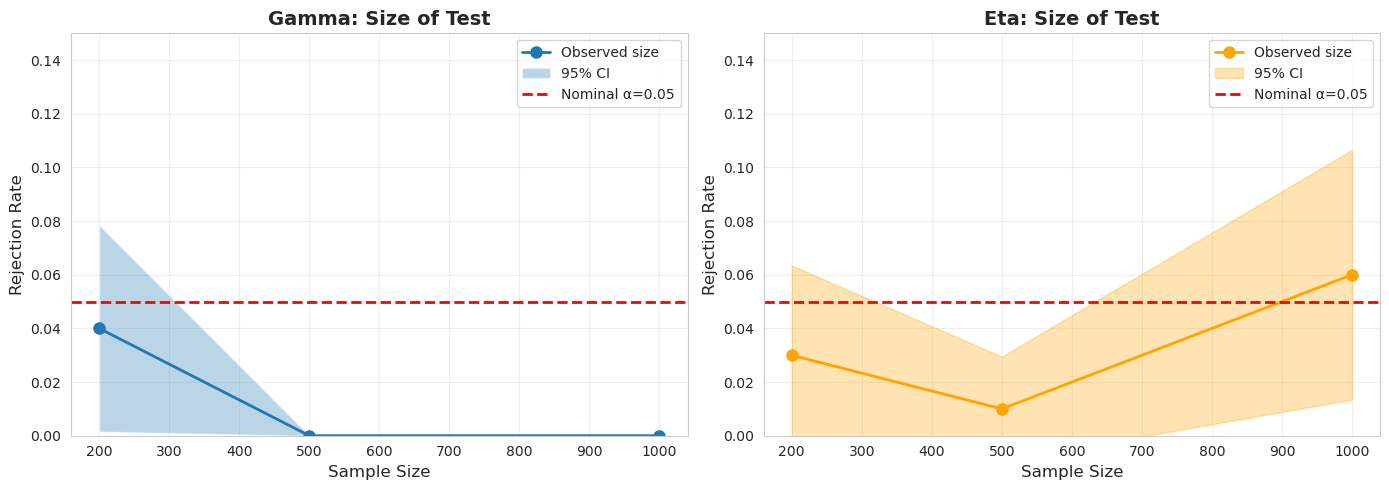


Interpretation:
- The test is well-calibrated if the observed size is close to the nominal α=0.05
- The 95% CI should contain the nominal α=0.05


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gamma size plot
ax = axes[0]
ax.plot(size_gamma['n_samples_train'], size_gamma['size'], 'o-', linewidth=2, markersize=8, label='Observed size')
ax.fill_between(size_gamma['n_samples_train'], 
                size_gamma['ci_lower'], 
                size_gamma['ci_upper'], 
                alpha=0.3, label='95% CI')
ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'Nominal α={alpha}')
ax.set_xlabel('Sample Size', fontsize=12)
ax.set_ylabel('Rejection Rate', fontsize=12)
ax.set_title('Gamma: Size of Test', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(0.15, size_gamma['ci_upper'].max() * 1.1)])

# Eta size plot
ax = axes[1]
ax.plot(size_eta['n_samples_train'], size_eta['size'], 'o-', linewidth=2, markersize=8, label='Observed size', color='orange')
ax.fill_between(size_eta['n_samples_train'], 
                size_eta['ci_lower'], 
                size_eta['ci_upper'], 
                alpha=0.3, label='95% CI', color='orange')
ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'Nominal α={alpha}')
ax.set_xlabel('Sample Size', fontsize=12)
ax.set_ylabel('Rejection Rate', fontsize=12)
ax.set_title('Eta: Size of Test', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, max(0.15, size_eta['ci_upper'].max() * 1.1)])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'inference_size_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- The test is well-calibrated if the observed size is close to the nominal α=0.05")
print("- The 95% CI should contain the nominal α=0.05")

## 3. Power Analysis

Analyze power (rejection rate) for different parameter values (gamma and eta) at α = 0.05.
Power should increase as the effect size increases.

In [6]:
def calculate_power(df, param_col, alpha=0.05):
    """
    Calculate power (rejection rate) for each parameter value, sample size, and pattern.
    """
    results = []
    
    for param_val in sorted(df[param_col].unique()):
        for n in sorted(df['n_samples_train'].unique()):
            for pattern in sorted(df['pattern'].unique()):
                # Filter data
                subset = df[(df[param_col] == param_val) & 
                           (df['n_samples_train'] == n) & 
                           (df['pattern'] == pattern)]
                
                # Calculate rejection rate
                n_total = len(subset)
                n_rejected = (subset['p_value'] < alpha).sum()
                rejection_rate = n_rejected / n_total if n_total > 0 else np.nan
                
                # Calculate 95% confidence interval
                if n_total > 0 and rejection_rate > 0 and rejection_rate < 1:
                    se = np.sqrt(rejection_rate * (1 - rejection_rate) / n_total)
                    ci_lower = rejection_rate - 1.96 * se
                    ci_upper = rejection_rate + 1.96 * se
                else:
                    ci_lower = rejection_rate
                    ci_upper = rejection_rate
                
                results.append({
                    param_col: param_val,
                    'n_samples_train': n,
                    'pattern': pattern,
                    'n_tests': n_total,
                    'n_rejected': n_rejected,
                    'power': rejection_rate,
                    'ci_lower': ci_lower,
                    'ci_upper': ci_upper
                })
    
    return pd.DataFrame(results)

# Calculate power for both experiments
power_gamma = calculate_power(df_gamma_power, 'gamma', alpha)
power_eta = calculate_power(df_eta_power, 'eta', alpha)

print("Gamma Power Analysis:")
print("=" * 70)
gamma_pivot = power_gamma.pivot_table(
    index='gamma', 
    columns=['n_samples_train', 'pattern'], 
    values='power'
)
print(gamma_pivot)

print("\n\nEta Power Analysis:")
print("=" * 70)
eta_pivot = power_eta.pivot_table(
    index='eta', 
    columns=['n_samples_train', 'pattern'], 
    values='power'
)
print(eta_pivot)

print("\nNote: Values show rejection rate at α=0.05 for each parameter value")

Gamma Power Analysis:
n_samples_train               200               500
pattern         conditional_chain conditional_chain
gamma                                              
1.0000                     0.6100            0.9900
2.0000                     0.9100            1.0000
3.0000                     0.9200            1.0000
4.0000                     0.9200            1.0000
5.0000                     0.9100            1.0000


Eta Power Analysis:
n_samples_train         200         500
pattern         conditional conditional
eta                                    
0.5000               0.2100      0.7500
0.7000               0.4500      0.9700
1.0000               0.7900      1.0000
2.0000               0.8400      1.0000
3.0000               0.8500      1.0000

Note: Values show rejection rate at α=0.05 for each parameter value


### 3.1 Visualize Gamma Power

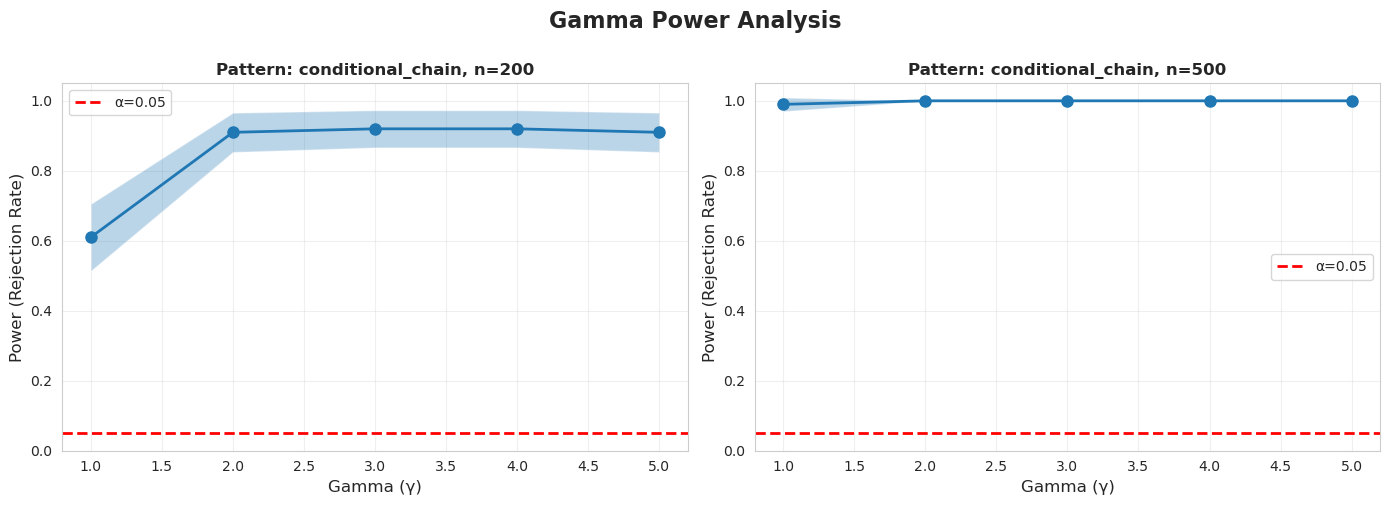

In [7]:
# Get unique sample sizes and patterns
sample_sizes = sorted(power_gamma['n_samples_train'].unique())
patterns = sorted(power_gamma['pattern'].unique())

fig, axes = plt.subplots(len(patterns), len(sample_sizes), 
                         figsize=(7*len(sample_sizes), 5*len(patterns)))

# Ensure axes is 2D
if len(patterns) == 1 and len(sample_sizes) == 1:
    axes = np.array([[axes]])
elif len(patterns) == 1:
    axes = axes.reshape(1, -1)
elif len(sample_sizes) == 1:
    axes = axes.reshape(-1, 1)

for i, pattern in enumerate(patterns):
    for j, n in enumerate(sample_sizes):
        ax = axes[i, j]
        
        # Filter data
        subset = power_gamma[(power_gamma['pattern'] == pattern) & 
                            (power_gamma['n_samples_train'] == n)]
        
        # Plot
        ax.plot(subset['gamma'], subset['power'], 'o-', linewidth=2, markersize=8)
        ax.fill_between(subset['gamma'], 
                       subset['ci_lower'], 
                       subset['ci_upper'], 
                       alpha=0.3)
        ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'α={alpha}')
        ax.set_xlabel('Gamma (γ)', fontsize=12)
        ax.set_ylabel('Power (Rejection Rate)', fontsize=12)
        ax.set_title(f'Pattern: {pattern}, n={n}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])

plt.suptitle('Gamma Power Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'inference_power_gamma_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2 Visualize Eta Power

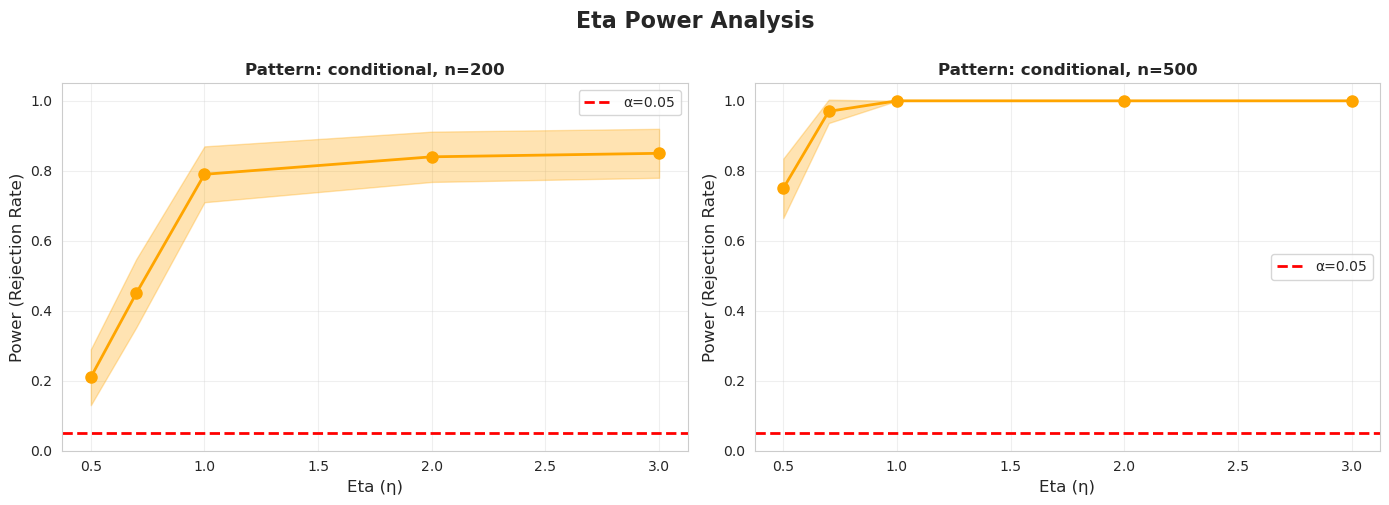

In [8]:
# Get unique sample sizes and patterns
sample_sizes = sorted(power_eta['n_samples_train'].unique())
patterns = sorted(power_eta['pattern'].unique())

fig, axes = plt.subplots(len(patterns), len(sample_sizes), 
                         figsize=(7*len(sample_sizes), 5*len(patterns)))

# Ensure axes is 2D
if len(patterns) == 1 and len(sample_sizes) == 1:
    axes = np.array([[axes]])
elif len(patterns) == 1:
    axes = axes.reshape(1, -1)
elif len(sample_sizes) == 1:
    axes = axes.reshape(-1, 1)

for i, pattern in enumerate(patterns):
    for j, n in enumerate(sample_sizes):
        ax = axes[i, j]
        
        # Filter data
        subset = power_eta[(power_eta['pattern'] == pattern) & 
                          (power_eta['n_samples_train'] == n)]
        
        # Plot
        ax.plot(subset['eta'], subset['power'], 'o-', linewidth=2, markersize=8, color='orange')
        ax.fill_between(subset['eta'], 
                       subset['ci_lower'], 
                       subset['ci_upper'], 
                       alpha=0.3, color='orange')
        ax.axhline(y=alpha, color='r', linestyle='--', linewidth=2, label=f'α={alpha}')
        ax.set_xlabel('Eta (η)', fontsize=12)
        ax.set_ylabel('Power (Rejection Rate)', fontsize=12)
        ax.set_title(f'Pattern: {pattern}, n={n}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])

plt.suptitle('Eta Power Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'inference_power_eta_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Summary Statistics

In [9]:
print("="*80)
print("SUMMARY: Size Analysis")
print("="*80)
print("\nGamma Size:")
print(size_gamma[['n_samples_train', 'size', 'ci_lower', 'ci_upper']].to_string(index=False))

print("\nEta Size:")
print(size_eta[['n_samples_train', 'size', 'ci_lower', 'ci_upper']].to_string(index=False))

print("\n" + "="*80)
print("SUMMARY: Power Analysis")
print("="*80)
print("\nGamma Power:")
print(gamma_pivot)

print("\nEta Power:")
print(eta_pivot)

# Save summary to CSV
size_gamma.to_csv(RESULTS_DIR / 'summary_size_gamma.csv', index=False)
size_eta.to_csv(RESULTS_DIR / 'summary_size_eta.csv', index=False)
power_gamma.to_csv(RESULTS_DIR / 'summary_power_gamma.csv', index=False)
power_eta.to_csv(RESULTS_DIR / 'summary_power_eta.csv', index=False)

print("\n" + "="*80)
print("Summary files saved:")
print("  - results/summary_size_gamma.csv")
print("  - results/summary_size_eta.csv")
print("  - results/summary_power_gamma.csv")
print("  - results/summary_power_eta.csv")
print("="*80)

SUMMARY: Size Analysis

Gamma Size:
 n_samples_train   size  ci_lower  ci_upper
             200 0.0400    0.0016    0.0784
             500 0.0000    0.0000    0.0000
            1000 0.0000    0.0000    0.0000

Eta Size:
 n_samples_train   size  ci_lower  ci_upper
             200 0.0300   -0.0034    0.0634
             500 0.0100   -0.0095    0.0295
            1000 0.0600    0.0135    0.1065

SUMMARY: Power Analysis

Gamma Power:
n_samples_train               200               500
pattern         conditional_chain conditional_chain
gamma                                              
1.0000                     0.6100            0.9900
2.0000                     0.9100            1.0000
3.0000                     0.9200            1.0000
4.0000                     0.9200            1.0000
5.0000                     0.9100            1.0000

Eta Power:
n_samples_train         200         500
pattern         conditional conditional
eta                                    
0.5000        

## 5. Interpretation

### Size Analysis
- **Goal**: The observed size should be close to the nominal significance level α = 0.05
- **Interpretation**: 
  - If size ≈ 0.05: Test is well-calibrated
  - If size > 0.05: Test is anti-conservative (too many false positives)
  - If size < 0.05: Test is conservative (too few rejections)

### Power Analysis
- **Goal**: Power should increase as the effect size (gamma or eta) increases
- **Interpretation**:
  - Higher power = better ability to detect true effects
  - Power should increase with sample size
  - Power should increase with effect size (distance from null hypothesis)